In [1]:
# ==========================================
# Customer Segmentation using RFM Analysis
# Syntecxhub Internship Project
# ==========================================

# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset

df = pd.read_csv(r'C:\Users\lohit\Downloads\Internships\SyntexHub\Week-2\Customer_Segmentation_using_RFM_Analysis\data\online_retail_II.csv', encoding='ISO-8859-1')

# Display first 5 rows
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# Shape of the dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

Shape: (1067371, 8)

Columns:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

Data Types:
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object


In [4]:
# Missing values

df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [6]:
df.shape

(1067371, 8)

In [7]:
# Check duplicate records

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 34335


In [8]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [9]:
# Remove rows where Customer ID is missing
df = df.dropna(subset=["Customer ID"])

# Check the new shape
print(df.shape)

(824364, 8)


In [10]:
# Count cancelled invoices
df[df["Invoice"].astype(str).str.startswith("C")].shape

(18744, 8)

In [11]:
df = df[~df["Invoice"].astype(str).str.startswith("C")]

print(df.shape)

(805620, 8)


In [12]:
# Check how many rows have Quantity <= 0
df[df["Quantity"] <= 0].shape

(0, 8)

In [13]:
df[df["Price"] <= 0].shape

(71, 8)

In [14]:
df[df["Price"] <= 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom
16107,490727,M,Manual,1,2009-12-07 16:38:00,0.0,17231.0,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
32916,492079,85042,ANTIQUE LILY FAIRY LIGHTS,8,2009-12-15 13:49:00,0.0,15070.0,United Kingdom
40101,492760,21143,ANTIQUE GLASS HEART DECORATION,12,2009-12-18 14:22:00,0.0,18071.0,United Kingdom
47126,493761,79320,FLAMINGO LIGHTS,24,2010-01-06 14:54:00,0.0,14258.0,United Kingdom
48342,493899,22355,"CHARLOTTE BAG , SUKI DESIGN",10,2010-01-08 10:43:00,0.0,12417.0,Belgium
57619,494607,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-15 12:43:00,0.0,16858.0,United Kingdom


In [15]:
df = df[df["Price"] > 0]

print(df.shape)

(805549, 8)


In [16]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 26124


In [17]:
df[df.duplicated()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
390,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01 11:34:00,2.55,16329.0,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
657,489529,22028,PENNY FARTHING BIRTHDAY CARD,12,2009-12-01 11:51:00,0.42,17984.0,United Kingdom
658,489529,22036,DINOSAUR BIRTHDAY CARD,12,2009-12-01 11:51:00,0.42,17984.0,United Kingdom


In [18]:
df = df.drop_duplicates()

print(df.shape)

(779425, 8)


In [19]:
df["TotalAmount"] = df["Quantity"] * df["Price"]

In [20]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [21]:
df.dtypes

Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
TotalAmount    float64
dtype: object

In [22]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [23]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
TotalAmount           float64
dtype: object

In [24]:
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [25]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [26]:

print(reference_date)

2011-12-10 12:50:00


In [27]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(reference_date)

2011-12-10 12:50:00


In [28]:
df.groupby("Customer ID")

In [29]:
grouped = df.groupby("Customer ID")

In [30]:
grouped.groups

{12346.0: [27994, 28251, 28254, 39398, 39411, 45228, 45230, 56117, 66084, 107800, 107801, 107802, 107803, 107804, 253028, 253029, 253030, 253031, 253032, 253033, 253034, 253035, 253036, 253037, 253038, 253039, 253040, 253041, 253042, 253043, 253044, 253045, 253046, 587080], 12347.0: [423892, 423893, 423894, 423895, 423896, 423897, 423898, 423899, 423900, 423901, 423902, 423903, 423904, 423905, 423906, 423907, 423908, 423909, 423910, 423911, 423912, 423913, 423914, 423915, 423916, 423917, 423918, 423919, 423920, 423921, 423922, 423923, 423924, 423925, 423926, 423927, 423928, 423929, 423930, 423931, 517876, 517877, 517878, 517879, 517880, 517881, 517882, 517883, 517884, 517885, 517886, 517887, 517888, 517889, 517890, 517891, 517892, 517893, 517894, 517895, 517896, 517897, 517898, 517899, 517900, 517901, 517902, 517903, 517904, 517905, 517906, 597707, 597708, 597709, 597710, 597711, 597712, 597713, 597714, 597715, 597716, 597717, 597718, 597719, 597720, 597721, 597722, 597723, 597724, 597

In [31]:


type(grouped)

pandas.core.groupby.generic.DataFrameGroupBy

In [32]:
grouped["TotalAmount"].sum()

Customer ID
12346.0    77556.46
12347.0     4921.53
12348.0     2019.40
12349.0     4428.69
12350.0      334.40
             ...   
18283.0     2664.90
18284.0      461.68
18285.0      427.00
18286.0     1296.43
18287.0     4182.99
Name: TotalAmount, Length: 5878, dtype: float64

In [33]:
rfm = df.groupby("Customer ID")

In [34]:
monetary = rfm["TotalAmount"].sum()


In [35]:
frequency = rfm["Invoice"].count()

In [36]:
rfm["InvoiceDate"].max()

Customer ID
12346.0   2011-01-18 10:01:00
12347.0   2011-12-07 15:52:00
12348.0   2011-09-25 13:13:00
12349.0   2011-11-21 09:51:00
12350.0   2011-02-02 16:01:00
                  ...        
18283.0   2011-12-06 12:02:00
18284.0   2010-10-04 11:33:00
18285.0   2010-02-17 10:24:00
18286.0   2010-08-20 11:57:00
18287.0   2011-10-28 09:29:00
Name: InvoiceDate, Length: 5878, dtype: datetime64[ns]

In [37]:
monetary = rfm["TotalAmount"].sum()
frequency = rfm["Invoice"].count()
recency = reference_date - rfm["InvoiceDate"].max()

In [38]:
#Build the RFM DataFrame.

rfm_df = pd.DataFrame({

SyntaxError: incomplete input (1353704661.py, line 3)

In [39]:
rfm_df = pd.DataFrame({
    "Monetary": rfm["TotalAmount"].sum(),
    "Frequency": rfm["Invoice"].count(),
    "Recency": (reference_date - rfm["InvoiceDate"].max()).dt.days
})

In [40]:
rfm_df.head()

,Monetary,Frequency,Recency
Customer ID,,,
12346.0,77556.46,34,326
12347.0,4921.53,222,2
12348.0,2019.40,51,75
12349.0,4428.69,175,19
12350.0,334.40,17,310


In [41]:
pd.qcut()

TypeError: qcut() missing 2 required positional arguments: 'x' and 'q'

In [42]:
pd.qcut(rfm_df["Recency"], q=5)

Customer ID
12346.0    (189.0, 410.0]
12347.0     (0.999, 19.0]
12348.0     (59.0, 189.0]
12349.0     (0.999, 19.0]
12350.0    (189.0, 410.0]
                ...      
18283.0     (0.999, 19.0]
18284.0    (410.0, 739.0]
18285.0    (410.0, 739.0]
18286.0    (410.0, 739.0]
18287.0      (19.0, 59.0]
Name: Recency, Length: 5878, dtype: category
Categories (5, interval[float64, right]): [(0.999, 19.0] < (19.0, 59.0] < (59.0, 189.0] < (189.0, 410.0] < (410.0, 739.0]]

In [43]:
rfm_df["R_Score"] = pd.qcut(
    rfm_df["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)

rfm_df["F_Score"] = pd.qcut(
    rfm_df["Frequency"],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

rfm_df["M_Score"] = pd.qcut(
    rfm_df["Monetary"],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

In [44]:
rfm_df.head()

,Monetary,Frequency,Recency,R_Score,F_Score,M_Score
Customer ID,,,,,,
12346.0,77556.46,34,326,2,2,5
12347.0,4921.53,222,2,5,5,5
12348.0,2019.40,51,75,3,3,4
12349.0,4428.69,175,19,5,5,5
12350.0,334.40,17,310,2,2,2


In [45]:
rfm_df["RFM_Score"] = rfm_df["R_Score"].astype(str) + rfm_df["F_Score"].astype(str) + rfm_df["M_Score"].astype(str)

In [46]:
rfm_df.head()

,Monetary,Frequency,Recency,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,77556.46,34,326,2,2,5,225
12347.0,4921.53,222,2,5,5,5,555
12348.0,2019.40,51,75,3,3,4,334
12349.0,4428.69,175,19,5,5,5,555
12350.0,334.40,17,310,2,2,2,222


In [47]:
def segment_customer(row):
    r = int(row["R_Score"])
    f = int(row["F_Score"])
    m = int(row["M_Score"])

    # Champions
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    # Loyal Customers
    elif r >= 3 and f >= 4:
        return "Loyal Customers"

    # Potential Loyalists
    elif r >= 4 and f >= 2:
        return "Potential Loyalists"

    # New Customers
    elif r == 5 and f == 1:
        return "New Customers"

    # At Risk
    elif r <= 2 and f >= 3:
        return "At Risk"

    # Lost Customers
    elif r <= 2 and f <= 2:
        return "Lost Customers"

    # Others
    else:
        return "Need Attention"

In [48]:
rfm_df["Segment"] = rfm_df.apply(segment_customer, axis=1)

In [49]:
rfm_df[["RFM_Score", "Segment"]].head(10)

,RFM_Score,Segment
Customer ID,,
12346.0,225,Lost Customers
12347.0,555,Champions
12348.0,334,Need Attention
12349.0,555,Champions
12350.0,222,Lost Customers
12351.0,222,Lost Customers
12352.0,444,Champions
12353.0,222,Lost Customers
12354.0,233,At Risk


In [50]:
rfm_df["Segment"].value_counts()

Segment
Lost Customers         1457
Champions              1273
At Risk                 890
Need Attention          818
Loyal Customers         691
Potential Loyalists     671
New Customers            78
Name: count, dtype: int64

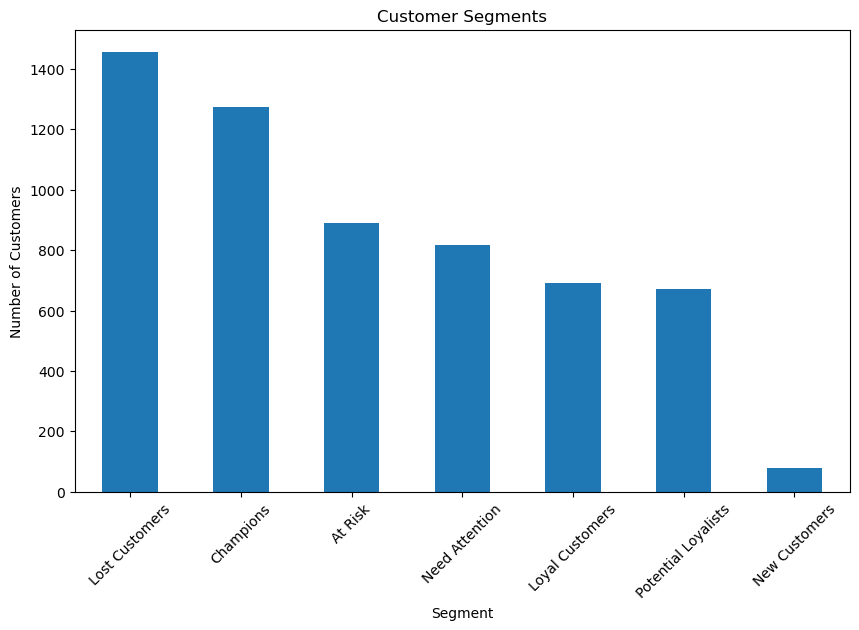

In [51]:
import matplotlib.pyplot as plt

segment_counts = rfm_df["Segment"].value_counts()

plt.figure(figsize=(10,6))
segment_counts.plot(kind="bar")
plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

In [52]:
rfm_df.groupby("Segment")[["Recency","Frequency","Monetary"]].mean().round(2)

,Recency,Frequency,Monetary
Segment,,,
At Risk,389.43,100.68,1681.40
Champions,19.99,386.52,9165.46
Lost Customers,450.95,16.10,512.95
Loyal Customers,81.07,176.04,2544.08
Need Attention,98.03,28.27,853.07
New Customers,10.55,8.85,2880.59
Potential Loyalists,25.83,43.02,1166.78


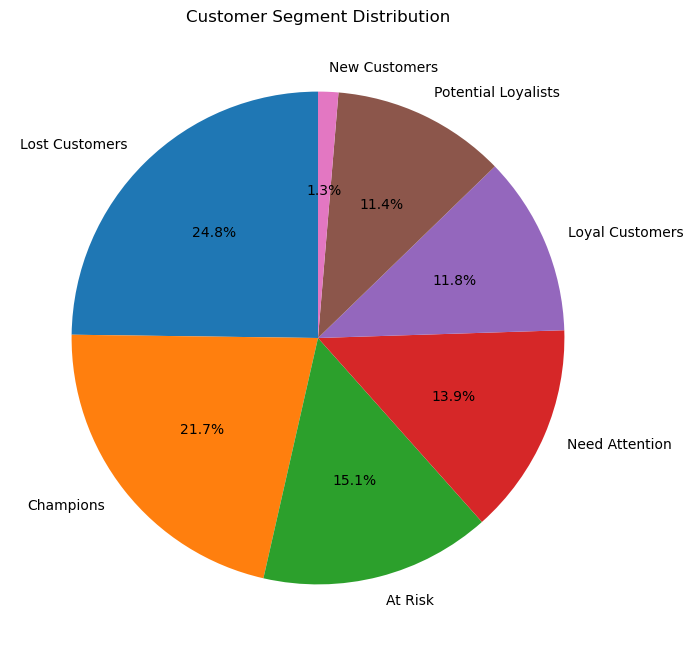

In [53]:
plt.figure(figsize=(8,8))
segment_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.ylabel("")
plt.title("Customer Segment Distribution")
plt.show()

In [54]:
rfm_df.to_csv("Customer_RFM_Segmentation.csv")